## Phiên bản được viết bằng Numba

In [1]:
import os
import sys
from pathlib import Path

In [2]:
current_path = Path().resolve()
while current_path.name != "APP-project":
    if current_path.parent == current_path:
        raise FileNotFoundError("❌ Không tìm thấy thư mục gốc 'APP-project'")
    current_path = current_path.parent

os.chdir(current_path)
# print(f"📂 Project root set to: {current_path}")

In [3]:
# !"D:\Download\Downloads\python.exe" -m pip install -r requirements_python311.txt

In [4]:
sys.path.append('Src')
from Src import func as func

import numpy as np
import matplotlib.pyplot as plt

from numpy.lib.stride_tricks import as_strided

import random
import math
import time

from numba import cuda, float32

import warnings
warnings.filterwarnings('ignore')

In [5]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Wed_Apr_17_19:36:51_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.5, V12.5.40
Build cuda_12.5.r12.5/compiler.34177558_0


In [6]:
!ptxas --version

ptxas: NVIDIA (R) Ptx optimizing assembler
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Wed_Apr_17_19:33:34_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.5, V12.5.40
Build cuda_12.5.r12.5/compiler.34177558_0


### Class Conv2D

In [78]:
@cuda.jit
def matmul_kernel(A, B, C):
    row, col = cuda.grid(2)
    if row < C.shape[0] and col < C.shape[1]:
        tmp = 0.
        for k in range(A.shape[1]):
            tmp += A[row, k] * B[k, col]
        C[row, col] = tmp

class Conv2D_CUDA:
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        limit = 0.1
        self.kernels = np.random.uniform(-limit, limit, (out_channels, kernel_size * kernel_size * in_channels)).astype(np.float32)
        self.biases = np.random.uniform(-limit, limit, out_channels).astype(np.float32)
        self.v_kernels = np.zeros_like(self.kernels)
        self.v_biases = np.zeros_like(self.biases)

    def im2col(self, input_data):
        N, H, W, C = input_data.shape
        k, s, p = self.kernel_size, self.stride, self.padding
        H_p, W_p = H + 2 * p, W + 2 * p
        out_h = (H_p - k) // s + 1
        out_w = (W_p - k) // s + 1

        padded = np.pad(input_data, ((0,0), (p,p), (p,p), (0,0)), mode='constant')
        cols = np.zeros((N, out_h * out_w, k * k * C), dtype=np.float32)

        for n in range(N):
            col_idx = 0
            for i in range(0, H_p - k + 1, s):
                for j in range(0, W_p - k + 1, s):
                    patch = padded[n, i:i+k, j:j+k, :]
                    cols[n, col_idx, :] = patch.reshape(-1)
                    col_idx += 1

        return cols, out_h, out_w

    def col2im(self, cols, input_shape):
        N, H, W, C = input_shape
        k, s, p = self.kernel_size, self.stride, self.padding
        H_p, W_p = H + 2 * p, W + 2 * p
        out_h = (H_p - k) // s + 1
        out_w = (W_p - k) // s + 1

        padded = np.zeros((N, H_p, W_p, C), dtype=np.float32)
        for n in range(N):
            col_idx = 0
            for i in range(0, H_p - k + 1, s):
                for j in range(0, W_p - k + 1, s):
                    patch = cols[n, col_idx, :].reshape((k, k, C))
                    padded[n, i:i+k, j:j+k, :] += patch
                    col_idx += 1

        return padded[:, p:p+H, p:p+W, :] if p > 0 else padded

    def forward(self, input_data):
        self.input_data = input_data
        self.cols, self.out_h, self.out_w = self.im2col(input_data)  # (N, L, K)
        N, L, K = self.cols.shape

        output = np.zeros((N, L, self.out_channels), dtype=np.float32)

        d_cols = cuda.to_device(np.ascontiguousarray(self.cols.reshape(-1, K)))
        d_kernels = cuda.to_device(np.ascontiguousarray(self.kernels.T))
        d_output = cuda.device_array((N * L, self.out_channels), dtype=np.float32)

        threads_per_block = (16, 16)
        blocks_x = (N * L + 15) // 16
        blocks_y = (self.out_channels + 15) // 16
        matmul_kernel[(blocks_x, blocks_y), threads_per_block](d_cols, d_kernels, d_output)

        result = d_output.copy_to_host().reshape(N, self.out_h, self.out_w, self.out_channels)
        result += self.biases.reshape((1, 1, 1, -1))
        return result

    def backward(self, grad_output):
        N, out_h, out_w, out_c = grad_output.shape
        L = out_h * out_w
        grad_output_reshaped = grad_output.reshape(N * L, out_c)
        cols_reshaped = self.cols.reshape(N * L, -1)

        # Gradient kernels: dL/dW = X.T @ dL/dY
        self.grad_kernels = np.dot(grad_output_reshaped.T, cols_reshaped).reshape(self.kernels.shape)

        # Gradient biases: dL/db = sum across all outputs
        self.grad_biases = np.sum(grad_output_reshaped, axis=0)

        # Gradient wrt input: dL/dX = dL/dY @ W.T then col2im
        grad_cols = np.dot(grad_output_reshaped, self.kernels)
        grad_cols = grad_cols.reshape(N, L, -1)
        grad_input = self.col2im(grad_cols, self.input_data.shape)
        return grad_input

    def step(self, lr, momentum):
        self.v_kernels = momentum * self.v_kernels - lr * self.grad_kernels
        self.v_biases = momentum * self.v_biases - lr * self.grad_biases

        self.kernels += self.v_kernels
        self.biases += self.v_biases

#### Test

In [10]:
# conv = Conv2D_CUDA(in_channels=3, out_channels=8, kernel_size=3, padding=1, stride=1)

# # Kiểm thử đầu ra
# output = conv.forward(X_train[:1])  # input shape: (1, 32, 32, 3)
# print("Output shape:", output.shape)

Output shape: (1, 32, 32, 8)


### Class ReLU

#### Forward

In [13]:
@cuda.jit
def relu_forward_kernel(input_tensor, output_tensor, mask, H, W, C):
    idx = cuda.grid(1)
    total = input_tensor.shape[0] * H * W * C
    if idx < total:
        n = idx // (H * W * C)
        h = (idx % (H * W * C)) // (W * C)
        w = (idx % (W * C)) // C
        c = idx % C

        val = input_tensor[n, h, w, c]
        if val > 0:
            output_tensor[n, h, w, c] = val
            mask[n, h, w, c] = 1
        else:
            output_tensor[n, h, w, c] = 0
            mask[n, h, w, c] = 0

#### Backward

In [12]:
@cuda.jit
def relu_backward_kernel(input, grad_output, grad_input):
    idx = cuda.grid(1)
    N, H, W, C = input.shape
    total = N * H * W * C

    if idx >= total:
        return

    c = idx % C
    idx //= C
    w = idx % W
    idx //= W
    h = idx % H
    n = idx // H

    grad_input[n, h, w, c] = grad_output[n, h, w, c] if input[n, h, w, c] > 0 else 0.0

#### Class ReLU_CUDA

In [41]:
class ReLU_CUDA:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = np.zeros_like(x, dtype=np.float32)
        output = np.zeros_like(x, dtype=np.float32)

        d_input = cuda.to_device(np.ascontiguousarray(x))
        d_output = cuda.to_device(np.ascontiguousarray(output))
        d_mask = cuda.to_device(np.ascontiguousarray(self.mask))

        N, H, W, C = x.shape
        threads_per_block = 256
        blocks_per_grid = (N * H * W * C + threads_per_block - 1) // threads_per_block

        relu_forward_kernel[blocks_per_grid, threads_per_block](d_input, d_output, d_mask, H, W, C)

        self.mask = d_mask.copy_to_host()
        return d_output.copy_to_host()

    def backward(self, grad_output):
        grad_input = np.zeros_like(grad_output, dtype=np.float32)

        d_grad_output = cuda.to_device(np.ascontiguousarray(grad_output))
        d_mask = cuda.to_device(np.ascontiguousarray(self.mask))
        d_grad_input = cuda.to_device(np.ascontiguousarray(grad_input))

        N, H, W, C = grad_output.shape
        threads_per_block = 256
        blocks_per_grid = (N * H * W * C + threads_per_block - 1) // threads_per_block

        relu_backward_kernel[blocks_per_grid, threads_per_block](d_grad_output, d_mask, d_grad_input, H, W, C)
        return d_grad_input.copy_to_host()

#### Test

In [81]:
# x_test = np.random.rand(1, 32, 32, 3).astype(np.float32)

# conv = Conv2D_CUDA(in_channels=3, out_channels=8, kernel_size=3, padding=1)
# relu = ReLU_CUDA()

# conv_out = conv.forward(x_test)
# relu_out = relu.forward(conv_out)

# print("Conv2D Output shape:", conv_out.shape)
# print("ReLU Output shape:", relu_out.shape)
# print("ReLU Output range:", relu_out.min(), "-", relu_out.max())

Conv2D Output shape: (1, 32, 32, 8)
ReLU Output shape: (1, 32, 32, 8)
ReLU Output range: 0.0 - 0.47505674


### Class MaxPool2D

#### Forward

In [17]:
@cuda.jit
def maxpool2d_forward_kernel(input_tensor, output_tensor, indices, ksize, stride, H_out, W_out):
    idx = cuda.grid(1)
    N, H, W, C = input_tensor.shape
    total = N * H_out * W_out * C
    if idx >= total:
        return

    n = idx // (H_out * W_out * C)
    h_out = (idx % (H_out * W_out * C)) // (W_out * C)
    w_out = (idx % (W_out * C)) // C
    c = idx % C

    h_start = h_out * stride
    w_start = w_out * stride

    max_val = -1e10
    max_idx = 0
    for i in range(ksize):
        for j in range(ksize):
            h = h_start + i
            w = w_start + j
            if h < H and w < W:
                val = input_tensor[n, h, w, c]
                if val > max_val:
                    max_val = val
                    max_idx = i * ksize + j

    output_tensor[n, h_out, w_out, c] = max_val
    indices[n, h_out, w_out, c] = max_idx

#### Backward

In [18]:
@cuda.jit
def maxpool2d_backward_kernel(grad_output, indices, grad_input, ksize, stride, H_out, W_out):
    idx = cuda.grid(1)
    N, H, W, C = grad_input.shape
    total = N * H_out * W_out * C
    if idx >= total:
        return

    n = idx // (H_out * W_out * C)
    h_out = (idx % (H_out * W_out * C)) // (W_out * C)
    w_out = (idx % (W_out * C)) // C
    c = idx % C

    max_idx = int(indices[n, h_out, w_out, c])
    i = max_idx // ksize
    j = max_idx % ksize

    h = h_out * stride + i
    w = w_out * stride + j
    if h < H and w < W:
        grad_input[n, h, w, c] += grad_output[n, h_out, w_out, c]

#### Class

In [42]:
class MaxPool2D_CUDA:
    def __init__(self, kernel_size=2, stride=2):
        self.kernel_size = kernel_size
        self.stride = stride
        self.indices = None
        self.input_shape = None

    def forward(self, x):
        self.input_shape = x.shape
        N, H, W, C = x.shape
        k, s = self.kernel_size, self.stride
        H_out = (H - k) // s + 1
        W_out = (W - k) // s + 1

        output = np.zeros((N, H_out, W_out, C), dtype=np.float32)
        indices = np.zeros_like(output, dtype=np.int32)

        d_input = cuda.to_device(np.ascontiguousarray(x))
        d_output = cuda.to_device(np.ascontiguousarray(output))
        d_indices = cuda.to_device(np.ascontiguousarray(indices))

        threads_per_block = 256
        blocks_per_grid = (N * H_out * W_out * C + threads_per_block - 1) // threads_per_block

        maxpool2d_forward_kernel[blocks_per_grid, threads_per_block](
            d_input, d_output, d_indices, k, s, H_out, W_out
        )

        self.indices = d_indices.copy_to_host()
        return d_output.copy_to_host()

    def backward(self, grad_output):
        N, H, W, C = self.input_shape
        k, s = self.kernel_size, self.stride
        H_out, W_out = grad_output.shape[1:3]

        grad_input = np.zeros((N, H, W, C), dtype=np.float32)
        d_grad_output = cuda.to_device(np.ascontiguousarray(grad_output))
        d_indices = cuda.to_device(np.ascontiguousarray(self.indices))
        d_grad_input = cuda.to_device(np.ascontiguousarray(grad_input))

        threads_per_block = 256
        blocks_per_grid = (N * H_out * W_out * C + threads_per_block - 1) // threads_per_block

        maxpool2d_backward_kernel[blocks_per_grid, threads_per_block](
            d_grad_output, d_indices, d_grad_input, k, s, H_out, W_out
        )

        return d_grad_input.copy_to_host()

#### Test

In [20]:
# np.random.seed(0)
# x = np.random.rand(32, 32, 3).astype(np.float32)

# # CUDA
# pool_cuda = MaxPool2D_CUDA()
# out_cuda = pool_cuda.forward(x[None, :, :, :])[0]

# out_cuda

array([[[0.5865129 , 0.71518934, 0.82894003],
        [0.735194  , 0.96218854, 0.96366274],
        [0.84640867, 0.952749  , 0.83261985],
        [0.81379783, 0.8817354 , 0.9786183 ],
        [0.9446689 , 0.639921  , 0.95608366],
        [0.56843394, 0.7742337 , 0.66017354],
        [0.6818203 , 0.616934  , 0.94374806],
        [0.6976312 , 0.43586493, 0.8965466 ],
        [0.9194826 , 0.9883738 , 0.998847  ],
        [0.6155596 , 0.86812603, 0.8480082 ],
        [0.807319  , 0.69742876, 0.6563296 ],
        [0.8558034 , 0.97645944, 0.9755215 ],
        [0.9767611 , 0.6048455 , 0.7392636 ],
        [0.9280813 , 0.7044144 , 0.6924721 ],
        [0.56660146, 0.934214  , 0.9292962 ],
        [0.7163272 , 0.6674104 , 0.730122  ]],

       [[0.49739137, 0.9443724 , 0.73955077],
        [0.8621915 , 0.97291946, 0.9608347 ],
        [0.9065555 , 0.7740473 , 0.8966713 ],
        [0.9903389 , 0.77058077, 0.7583786 ],
        [0.8310484 , 0.6289818 , 0.8726507 ],
        [0.95279163, 0.7980468 ,

### Conv Block

In [21]:
class ConvBlock_CUDA:
    def __init__(self, in_channels, out_channels, num_convs=2, padding=1, stride=1):
        self.convs = []
        self.relus = []

        for _ in range(num_convs):
            conv = Conv2D_CUDA(in_channels, out_channels, kernel_size=3, padding=padding, stride=stride)
            relu = ReLU_CUDA()
            self.convs.append(conv)
            self.relus.append(relu)
            in_channels = out_channels  # chuẩn bị cho conv tiếp theo

        self.pool = MaxPool2D_CUDA(kernel_size=2, stride=2)

    def forward(self, input):
        x = input
        for conv, relu in zip(self.convs, self.relus):
            x = conv.forward(x)
            x = relu.forward(x)
        x = self.pool.forward(x)
        return x

    def backward(self, d_out):
        d_out = self.pool.backward(d_out)
        for conv, relu in zip(reversed(self.convs), reversed(self.relus)):
            d_out = relu.backward(d_out)
            d_out = conv.backward(d_out)
        return d_out

    def step(self, learning_rate, momentum=0.9):
        for conv in self.convs:
            conv.step(learning_rate, momentum)

#### Test

In [22]:
# block = ConvBlock_CUDA(3, 64, num_convs=2)
# x = np.random.rand(1, 32, 32, 3).astype(np.float32)
# out = block.forward(x)
# print(out.shape)  # expect (1, 16, 16, 64)

(1, 16, 16, 64)


### Class Flatten

In [23]:
class Flatten_CUDA:
    def __init__(self):
        self.input_shape = None

    def forward(self, input):
        # Lưu lại shape ban đầu (N, H, W, C)
        self.input_shape = input.shape
        return input.reshape(input.shape[0], -1)  # giữ batch dim

    def backward(self, grad_output):
        return grad_output.reshape(self.input_shape)

### Class Fully Connected Layer

#### Forward

In [24]:
@cuda.jit
def fc_forward_kernel(input_vec, weights, bias, output):
    i = cuda.grid(1)
    if i < weights.shape[1]:  # output dim
        tmp = 0.
        for j in range(weights.shape[0]):  # input dim
            tmp += input_vec[j] * weights[j, i]
        output[i] = tmp + bias[i]

#### Backward

In [25]:
@cuda.jit
def fc_backward_kernel(grad_output, weights, grad_input):
    i = cuda.grid(1)
    if i < weights.shape[0]:  # input dim
        tmp = 0.
        for j in range(weights.shape[1]):
            tmp += grad_output[j] * weights[i, j]
        grad_input[i] = tmp

#### Class

In [44]:
class FullyConnected_CUDA:
    def __init__(self, in_dim, out_dim):
        limit = 0.01
        self.W = np.random.uniform(-limit, limit, (in_dim, out_dim)).astype(np.float32)
        self.b = np.random.uniform(-limit, limit, out_dim).astype(np.float32)
        self.v_W = np.zeros_like(self.W)
        self.v_b = np.zeros_like(self.b)

    def forward(self, x):
        self.input = x.astype(np.float32).flatten()  # đảm bảo là 1D vector
        output = np.zeros_like(self.b)

        d_input = cuda.to_device(np.ascontiguousarray(self.input))
        d_W = cuda.to_device(np.ascontiguousarray(self.W))
        d_b = cuda.to_device(np.ascontiguousarray(self.b))
        d_out = cuda.to_device(np.ascontiguousarray(output))

        threads = 128
        blocks = (self.W.shape[1] + threads - 1) // threads
        fc_forward_kernel[blocks, threads](d_input, d_W, d_b, d_out)

        return d_out.copy_to_host()

    def backward(self, grad_output):
        self.grad_W = np.outer(self.input, grad_output).astype(np.float32)
        self.grad_b = grad_output.astype(np.float32)

        grad_input = np.zeros_like(self.input)
        d_grad_output = cuda.to_device(np.ascontiguousarray(grad_output.astype(np.float32)))
        d_W = cuda.to_device(np.ascontiguousarray(self.W))
        d_grad_input = cuda.to_device(np.ascontiguousarray(grad_input))

        threads = 128
        blocks = (self.W.shape[0] + threads - 1) // threads
        fc_backward_kernel[blocks, threads](d_grad_output, d_W, d_grad_input)

        return d_grad_input.copy_to_host()

    def step(self, learning_rate, momentum=0.9):
        self.v_W = momentum * self.v_W - learning_rate * self.grad_W
        self.v_b = momentum * self.v_b - learning_rate * self.grad_b
        self.W += self.v_W
        self.b += self.v_b

#### Test

In [27]:
# fc = FullyConnected_CUDA(in_dim=128, out_dim=10)
# x = np.random.rand(128).astype(np.float32)
# out = fc.forward(x)
# print(out.shape)  # (10,)

(10,)


### Class ReLU cho vector

#### Forward

In [28]:
@cuda.jit
def relu_vector_forward_kernel(x, y, mask):
    i = cuda.grid(1)
    if i < x.size:
        val = x[i]
        if val > 0:
            y[i] = val
            mask[i] = 1
        else:
            y[i] = 0
            mask[i] = 0

#### Backward

In [29]:
@cuda.jit
def relu_vector_backward_kernel(grad_output, mask, grad_input):
    i = cuda.grid(1)
    if i < grad_output.size:
        grad_input[i] = grad_output[i] * mask[i]

#### Class

In [45]:
class ReLUVector_CUDA:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        x = np.ascontiguousarray(x.astype(np.float32))
        y = np.ascontiguousarray(np.zeros_like(x))
        self.mask = np.ascontiguousarray(np.zeros_like(x, dtype=np.float32))

        d_x = cuda.to_device(x)
        d_y = cuda.to_device(y)
        d_mask = cuda.to_device(self.mask)

        threads = 128
        blocks = (x.size + threads - 1) // threads
        relu_vector_forward_kernel[blocks, threads](d_x, d_y, d_mask)

        self.mask = d_mask.copy_to_host()
        return d_y.copy_to_host()

    def backward(self, grad_output):
        grad_output = np.ascontiguousarray(grad_output.astype(np.float32))
        grad_input = np.ascontiguousarray(np.zeros_like(grad_output))

        d_grad_output = cuda.to_device(grad_output)
        d_mask = cuda.to_device(np.ascontiguousarray(self.mask))
        d_grad_input = cuda.to_device(grad_input)

        threads = 128
        blocks = (grad_output.size + threads - 1) // threads
        relu_vector_backward_kernel[blocks, threads](d_grad_output, d_mask, d_grad_input)

        return d_grad_input.copy_to_host()

#### Test

In [46]:
x = np.random.randn(10).astype(np.float32)
relu_vec = ReLUVector_CUDA()
out = relu_vec.forward(x)
grad = relu_vec.backward(np.ones_like(out))
print("Output:", out)
print("Grad:", grad)

Output: [0.95008844 0.         0.         0.41059852 0.14404356 1.4542735
 0.7610377  0.12167501 0.44386324 0.33367434]
Grad: [1. 0. 0. 1. 1. 1. 1. 1. 1. 1.]


### Class Softmax + CrossEntropyLoss

In [47]:
@cuda.jit
def softmax_kernel(x, max_val, sum_exp, out):
    i = cuda.grid(1)
    if i < x.size:
        out[i] = math.exp(x[i] - max_val[0]) / sum_exp[0]

class Softmax_CUDA:
    def __init__(self):
        self.output = None
        self.input = None

    def forward(self, x):
        self.input = np.ascontiguousarray(x.astype(np.float32))
        x_max = np.max(self.input)
        x_stable = self.input - x_max
        exps = np.exp(x_stable)
        sum_exp = np.sum(exps)

        # Đảm bảo tất cả buffer đưa lên GPU đều contiguous
        d_x = cuda.to_device(self.input)
        d_out = cuda.device_array_like(self.input)
        d_max = cuda.to_device(np.ascontiguousarray(np.array([x_max], dtype=np.float32)))
        d_sum = cuda.to_device(np.ascontiguousarray(np.array([sum_exp], dtype=np.float32)))

        threads = 128
        blocks = (x.size + threads - 1) // threads
        softmax_kernel[blocks, threads](d_x, d_max, d_sum, d_out)

        self.output = d_out.copy_to_host()
        return self.output

class CrossEntropyLoss_CUDA:
    def __init__(self):
        self.pred_probs = None
        self.target_onehot = None

    def forward(self, pred_probs, target_onehot):
        self.pred_probs = pred_probs
        self.target_onehot = target_onehot.astype(np.float32)
        return -np.sum(self.target_onehot * np.log(pred_probs + 1e-12))

    def backward(self):
        return self.pred_probs - self.target_onehot

### Class Cấu Trúc

In [33]:
class SimpleCNN_CUDA:
    def __init__(self):
        self.block1 = ConvBlock_CUDA(3, 64, num_convs=2, padding=1)
        self.block2 = ConvBlock_CUDA(64, 128, num_convs=2, padding=1)
        self.block3 = ConvBlock_CUDA(128, 256, num_convs=2, padding=1)

        self.flatten = Flatten_CUDA()
        self.fc1 = FullyConnected_CUDA(256 * 4 * 4, 512)
        self.relu_fc1 = ReLUVector_CUDA()
        self.fc2 = FullyConnected_CUDA(512, 10)
        self.softmax = Softmax_CUDA()

### Train

In [36]:
def train_cuda(model, train_data, train_labels, epochs=10, learning_rate=0.01,
               mb_size=32, momentum=0.9, lr_decay_factor=0.5,
               log_filename="training_log_cuda.csv", detail_log_filename="details_log_cuda.csv"):

    np.random.seed(0)
    best_train_acc = 0
    plateau_count = 0
    patience = 2

    loss_fn = CrossEntropyLoss_CUDA()
    n_samples = train_data.shape[0]
    indices = np.arange(n_samples)

    for epoch in range(epochs):
        start_epoch = time.time()
        total_loss = 0.0
        correct = 0

        conv2d_time = relu_time = maxpool_time = flatten_time = fc_time = softmax_time = 0.0

        np.random.shuffle(indices)
        train_data_shuffled = train_data[indices]
        train_labels_shuffled = train_labels[indices]

        full_batch_count = n_samples // mb_size
        for i in range(full_batch_count):
            start = i * mb_size
            end = start + mb_size
            X_batch = train_data_shuffled[start:end]
            y_batch = train_labels_shuffled[start:end]

            for x, target in zip(X_batch, y_batch):
                x = x[None, ...]
                out = x
                for conv, relu in zip(model.block1.convs, model.block1.relus):
                    t0 = time.time(); out = conv.forward(out); t1 = time.time(); conv2d_time += t1 - t0
                    t0 = time.time(); out = relu.forward(out); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); out = model.block1.pool.forward(out); t1 = time.time(); maxpool_time += t1 - t0

                for conv, relu in zip(model.block2.convs, model.block2.relus):
                    t0 = time.time(); out = conv.forward(out); t1 = time.time(); conv2d_time += t1 - t0
                    t0 = time.time(); out = relu.forward(out); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); out = model.block2.pool.forward(out); t1 = time.time(); maxpool_time += t1 - t0

                for conv, relu in zip(model.block3.convs, model.block3.relus):
                    t0 = time.time(); out = conv.forward(out); t1 = time.time(); conv2d_time += t1 - t0
                    t0 = time.time(); out = relu.forward(out); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); out = model.block3.pool.forward(out); t1 = time.time(); maxpool_time += t1 - t0

                t0 = time.time(); out = model.flatten.forward(out); t1 = time.time(); flatten_time += t1 - t0
                t0 = time.time(); out = model.fc1.forward(out); t1 = time.time(); fc_time += t1 - t0
                t0 = time.time(); out = model.relu_fc1.forward(out); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); out = model.fc2.forward(out); t1 = time.time(); fc_time += t1 - t0
                t0 = time.time(); pred_probs = model.softmax.forward(out); t1 = time.time(); softmax_time += t1 - t0

                loss = loss_fn.forward(pred_probs, target)
                total_loss += loss
                if np.argmax(pred_probs) == np.argmax(target):
                    correct += 1

                t0 = time.time(); grad = loss_fn.backward(); t1 = time.time(); softmax_time += t1 - t0
                t0 = time.time(); grad = model.fc2.backward(grad); t1 = time.time(); fc_time += t1 - t0
                t0 = time.time(); grad = model.relu_fc1.backward(grad); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); grad = model.fc1.backward(grad); t1 = time.time(); fc_time += t1 - t0
                t0 = time.time(); grad = model.flatten.backward(grad); t1 = time.time(); flatten_time += t1 - t0

                t0 = time.time(); grad = model.block3.pool.backward(grad); t1 = time.time(); maxpool_time += t1 - t0
                for conv, relu in zip(reversed(model.block3.convs), reversed(model.block3.relus)):
                    t0 = time.time(); grad = relu.backward(grad); t1 = time.time(); relu_time += t1 - t0
                    t0 = time.time(); grad = conv.backward(grad); t1 = time.time(); conv2d_time += t1 - t0

                t0 = time.time(); grad = model.block2.pool.backward(grad); t1 = time.time(); maxpool_time += t1 - t0
                for conv, relu in zip(reversed(model.block2.convs), reversed(model.block2.relus)):
                    t0 = time.time(); grad = relu.backward(grad); t1 = time.time(); relu_time += t1 - t0
                    t0 = time.time(); grad = conv.backward(grad); t1 = time.time(); conv2d_time += t1 - t0

                t0 = time.time(); grad = model.block1.pool.backward(grad); t1 = time.time(); maxpool_time += t1 - t0
                for conv, relu in zip(reversed(model.block1.convs), reversed(model.block1.relus)):
                    t0 = time.time(); grad = relu.backward(grad); t1 = time.time(); relu_time += t1 - t0
                    t0 = time.time(); grad = conv.backward(grad); t1 = time.time(); conv2d_time += t1 - t0

                model.fc2.step(learning_rate, momentum)
                model.fc1.step(learning_rate, momentum)
                model.block3.step(learning_rate, momentum)
                model.block2.step(learning_rate, momentum)
                model.block1.step(learning_rate, momentum)

        end_epoch = time.time()
        epoch_time = end_epoch - start_epoch
        accuracy = correct / (full_batch_count * mb_size)

        func.log_training_details(epoch, epochs, epoch_time, n_samples, total_loss / (full_batch_count * mb_size), accuracy, log_filename)
        func.log_details(f"Epoch_{epoch+1}", mb_size, conv2d_time, relu_time, maxpool_time, flatten_time, fc_time, softmax_time, detail_log_filename)

        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/(full_batch_count * mb_size):.4f} - Acc: {accuracy:.4f} - Time: {epoch_time:.2f}s")
        print(f"    Conv2D: {conv2d_time:.2f}s | ReLU: {relu_time:.2f}s | MaxPool: {maxpool_time:.2f}s | Flatten: {flatten_time:.2f}s | FC: {fc_time:.2f}s | Softmax: {softmax_time:.2f}s\n")

        if epoch == 0:
            best_train_acc = accuracy
            plateau_count = 0
        else:
            if accuracy > best_train_acc:
                best_train_acc = accuracy
                plateau_count = 0
            else:
                plateau_count += 1
                if plateau_count >= patience:
                    learning_rate *= lr_decay_factor
                    plateau_count = 0
                    print(f"⚠️  ReduceLROnPlateau: Learning rate reduced to {learning_rate:.6f}")

In [8]:
def preprocess_cifar10_data():
    X_train, y_train, X_test, y_test = func.load_cifar10_data()

    # Chuyển từ (N, C, H, W) -> (N, H, W, C) và chuẩn hóa về [0, 1]
    X_train = X_train.transpose(0, 2, 3, 1).astype(np.float32) / 255.0
    X_test = X_test.transpose(0, 2, 3, 1).astype(np.float32) / 255.0

    # One-hot encoding cho nhãn
    num_classes = 10
    y_train_onehot = np.eye(num_classes)[y_train]
    y_test_onehot = np.eye(num_classes)[y_test]

    return X_train, y_train_onehot, X_test, y_test_onehot

In [9]:
X_train, y_train_onehot, X_test, y_test_onehot = preprocess_cifar10_data()

In [67]:
model = SimpleCNN_CUDA()
train_cuda(
    model,
    X_train[:10],  # train thử 10 mẫu đầu
    y_train_onehot[:10],
    epochs=1,        # train thử 1 epoch
    learning_rate=0.001,
    momentum=0.9,
    lr_decay_factor=0.5,
    mb_size=2,
    log_filename="Data/log/training_log_cuda_ver2_10.csv",
    detail_log_filename="Data/log/details_log_cuda_ver2_10.csv"
)

Epoch 1/1 - Loss: 2.3125 - Acc: 0.2000 - Time: 1.74s
    Conv2D: 0.79s | ReLU: 0.31s | MaxPool: 0.11s | Flatten: 0.00s | FC: 0.32s | Softmax: 0.01s



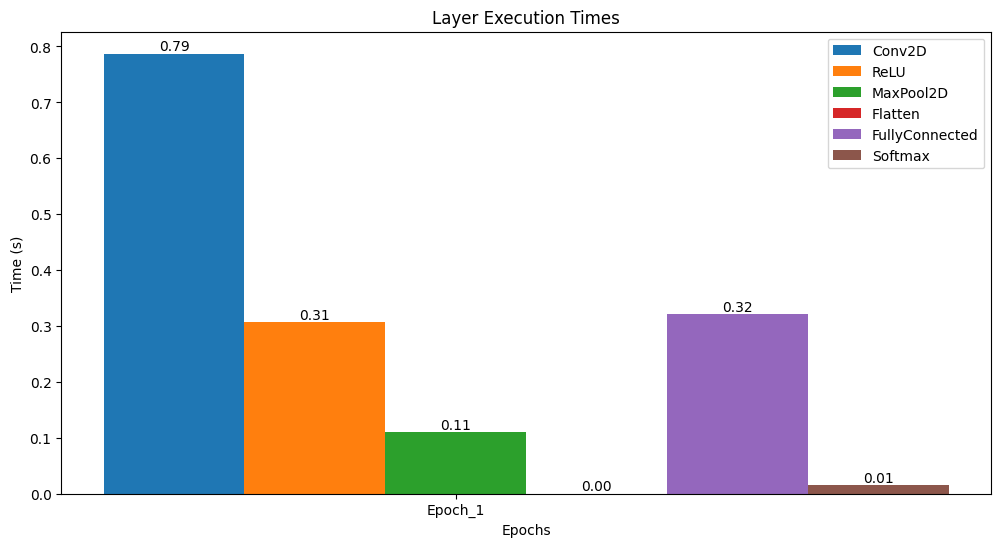

In [68]:
func.plot_details(
    "Data/log/details_log_cuda_ver2_10.csv"
)

In [69]:
model_2 = SimpleCNN_CUDA()
train_cuda(
    model_2,
    X_train,
    y_train_onehot,
    epochs=1,        # train thử 1 epoch
    learning_rate=0.001,
    momentum=0.9,
    lr_decay_factor=0.5,
    mb_size=64,
    log_filename="Data/log/training_log_cuda_ver2_50000.csv",
    detail_log_filename="Data/log/details_log_cuda_ver2_50000.csv"
)

Epoch 1/1 - Loss: 1.6002 - Acc: 0.4150 - Time: 7457.93s
    Conv2D: 3420.57s | ReLU: 1214.66s | MaxPool: 447.65s | Flatten: 0.38s | FC: 1271.87s | Softmax: 54.76s



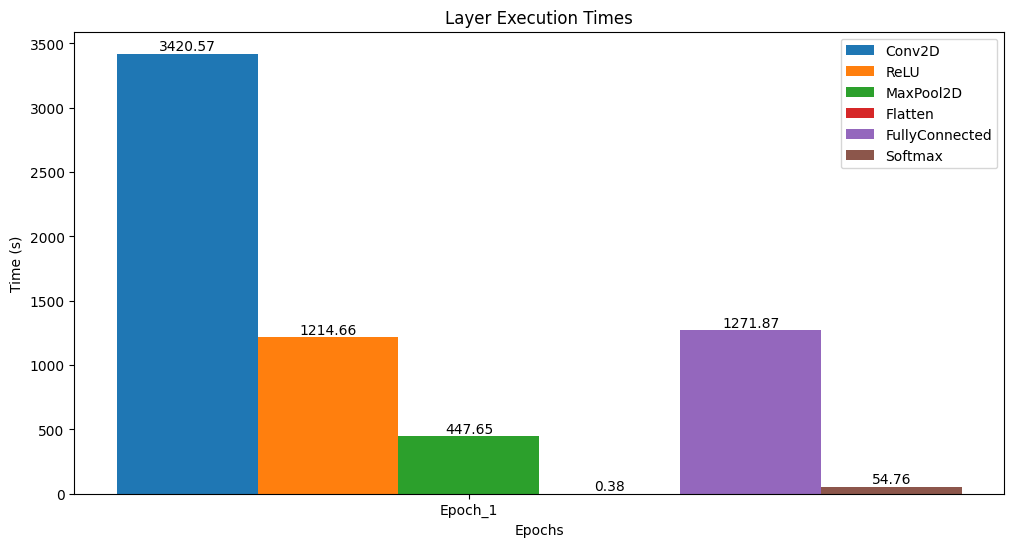

In [70]:
func.plot_details(
    "Data/log/details_log_cuda_ver2_50000.csv"
)

### So sánh 1 epoch giữa Numba và Numba ver 2

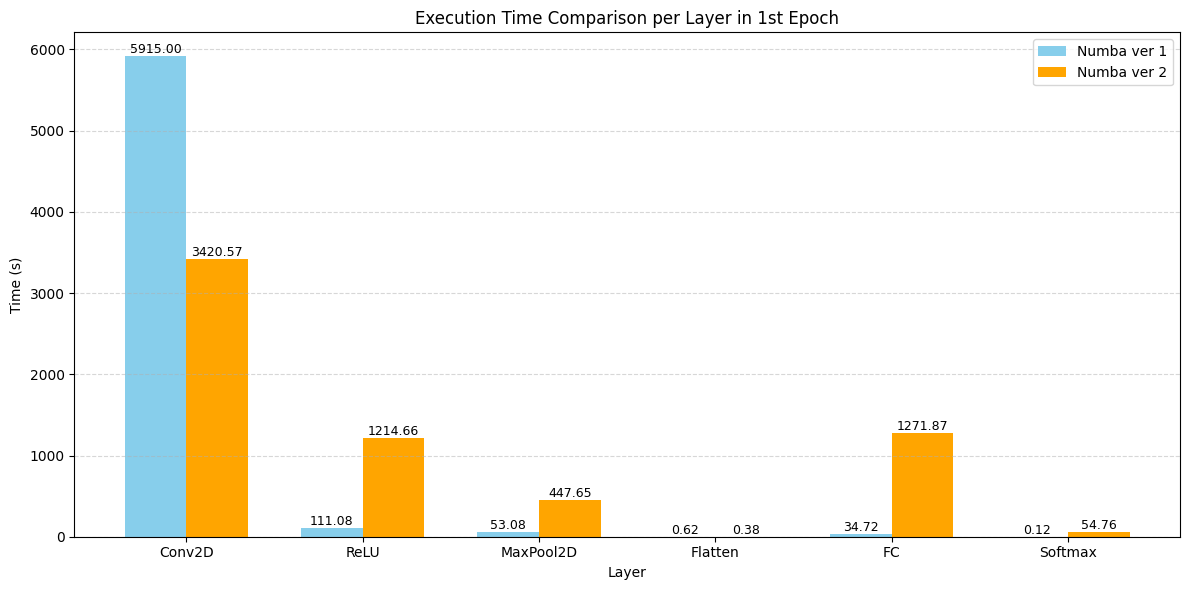

In [77]:
func.plot_compare_details_customized(
    "Data/log/details_log_cuda_50000.csv",
    "Data/log/details_log_cuda_ver2_50000.csv",
    "Numba ver 1",
    "Numba ver 2"
)